In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from eval.data import load_and_split
from medal.model import AutoEncoder
from utils import make_artificial_batches
import seaborn as sns
import torch
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from openTSNE import TSNE
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import numpy as np
import joblib
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-29 15:25:30,278	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-29 15:25:30,921	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
# Set MEDAL_DATA_DIR to your drd_data directory
import os
PATH_PREFIX = os.environ.get('MEDAL_DATA_DIR', os.path.join(os.path.expanduser('~'), 'drd_data'))
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,       
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

### Macaque

In [4]:
import pickle
teacher_embed = np.load(Path(PATH_PREFIX) / "embeddings2/macaque_umap_6_0.1_0_train.npy")
in_path = Path(PATH_PREFIX) / "embeddings2" / "macaque_umap_6_0.1_0_train.pkl"
with open(in_path, "rb") as f:
    umap_model = pickle.load(f)

In [5]:
X_og, X_test, y_og, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

In [6]:
cmap = plt.get_cmap("tab20")
cell_types = np.unique(y)
c_dict = {
    'Cones': '#E63946',  # red
    'HC':    '#2196F3',  # blue
    'RGC':   '#FF9800',  # orange
    'MG':    '#4CAF50',  # green
    'BC':    '#9C27B0',  # purple
    'AC':    '#00BCD4',  # cyan
    'Rods':  '#F06292',  # pink
    'Endo':  '#8D6E63',  # brown
    'Mic':   '#78909C',  # slate
    'Peri':  '#CDDC39',  # yellow-green
}


In [7]:
student = load_trained_ae(Path(PATH_PREFIX) / 'tmp_results/chkpt_teacher_seed/macaque/medal_umap2_6_0.1_tc0_0_ckpts/final.pt',
                input_dim=100,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=True)
student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
student_test_recon, student_test_embed = student(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
per_sample_test_recon = np.mean((student_test_recon.detach().numpy() - X_test)**2, axis=1)

/tmp/ipykernel_41535/562661432.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0


In [8]:
macaque2 = pd.read_csv(Path(PATH_PREFIX) /'macaque2_pc100.csv')
macaque3 = pd.read_csv(Path(PATH_PREFIX) / 'macaque3_pc100.csv')
_, macaque2_test = train_test_split(macaque2, test_size=9600, random_state=0)
_, macaque3_test = train_test_split(macaque3, test_size=9600, random_state=0)
X2, y2 = macaque2_test.drop('labels', axis=1).values, macaque2_test['labels'].values
X3, y3 = macaque3_test.drop('labels', axis=1).values, macaque3_test['labels'].values
X2_aug, X3_aug = np.vstack([X2, X_test]), np.vstack([X3, X_test])
y2_aug, y3_aug = np.concatenate([y2, y_test]), np.concatenate([y3, y_test])
m_id2 = np.array(['M2 (OOD)'] * len(y2)+['M1 (in-dist)'] * len(y_test))
m_id3 = np.array(['M3 (OOD)'] * len(y3)+['M1 (in-dist)'] * len(y_test))

In [9]:
batch_recon2, batch_embed2 = student(torch.tensor(X2_aug, dtype=torch.float32))
per_sample_recon_2 = np.mean((batch_recon2.detach().numpy() - X2_aug)**2, axis=1)
batch_recon3, batch_embed3 = student(torch.tensor(X3_aug, dtype=torch.float32))
per_sample_recon_3 = np.mean((batch_recon3.detach().numpy() - X3_aug)**2, axis=1)

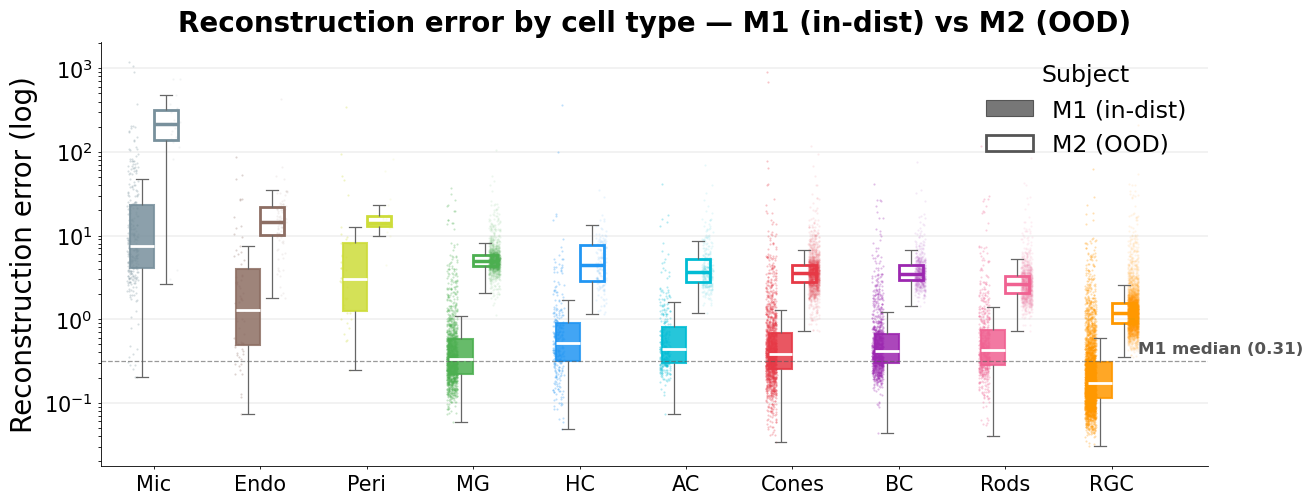

In [39]:
combined = pd.DataFrame({"cell_type": y2_aug, "Subject": m_id2, "recon_err": per_sample_recon_2})

medians = (
    combined
    .groupby(['cell_type', 'Subject'])['recon_err']
    .median()
    .unstack('Subject')
)
medians['diff'] = (medians['M2 (OOD)'] - medians['M1 (in-dist)']).abs()
cell_order = medians.sort_values('diff', ascending=False).index.tolist()
subject_order = ['M1 (in-dist)', 'M2 (OOD)']
n_ct, n_sub   = len(cell_order), len(subject_order)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 12,
    'xtick.labelsize': 15, 'ytick.labelsize': 15,
    'axes.linewidth': 0.6, 'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(13, 5))
def recolor_by_group(items, get_x_fn, apply_fn):
    tagged = sorted([(get_x_fn(obj), obj) for obj in items], key=lambda t: t[0])
    groups = {}
    for x, obj in tagged:
        ci = np.clip(int(round(x)), 0, n_ct - 1)
        groups.setdefault(ci, []).append((x, obj))
    for ci, members in groups.items():
        members.sort(key=lambda t: t[0]) 
        for si, (_, obj) in enumerate(members):
            if si < n_sub:
                apply_fn(obj, ci, si)
                
n_coll_before = len(ax.collections)
sns.stripplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    dodge=True, size=1.5, jitter=True, linewidth=0,
    legend=False, ax=ax, zorder=1,
)
new_colls = ax.collections[n_coll_before:]

def apply_strip(coll, ci, si):
    color = c_dict[cell_order[ci]]
    coll.set_facecolor(color)
    coll.set_alpha(0.30 if si == 0 else 0.10)

recolor_by_group(new_colls,
                 lambda c: float(np.mean(c.get_offsets()[:, 0])) if len(c.get_offsets()) else 0.,
                 apply_strip)

n_patch_before = len(ax.patches)
sns.boxplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    width=0.45, showcaps=True,
    boxprops={'linewidth': 1.5},
    medianprops={'linewidth': 2.0, 'color': 'white'},
    whiskerprops={'linewidth': 0.9},
    capprops={'linewidth': 0.9},
    showfliers=False, dodge=True, ax=ax, zorder=2,
)
new_patches = [p for p in ax.patches[n_patch_before:]
               if isinstance(p, mpatches.PathPatch)]

def apply_box(patch, ci, si):
    color = c_dict[cell_order[ci]]
    if si == 0:
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.85)
    else:
        patch.set_facecolor('none')
        patch.set_edgecolor(color)
        patch.set_linewidth(2.0)
        patch.set_alpha(1.0)         
recolor_by_group(new_patches,
                 lambda p: float(np.mean(p.get_path().vertices[:, 0])),
                 apply_box)

for line in ax.lines:
    x_data = line.get_xdata()
    if len(x_data) == 2 and line.get_linewidth() >= 1.8:
        x_mid = float(np.mean(x_data))
        ci = np.clip(int(round(x_mid)), 0, n_ct - 1)
        color = c_dict[cell_order[ci]]
        if x_mid > ci:
            line.set_color(color)  
            line.set_linewidth(2.5)
        else:
            line.set_color('white')     

m1_median = combined.loc[combined['Subject'] == 'M1 (in-dist)', 'recon_err'].median()
ax.axhline(m1_median, ls='--', lw=0.9, color='#555555', alpha=0.6)
ax.text(n_ct + 0.8, m1_median * 1.15,
        f'M1 median ({m1_median:.2f})',
        fontsize=12, fontweight='bold', color='#555555', va='bottom', ha='right')

ax.set_yscale('log')
ax.set_xlim(-0.5, n_ct - 0.5 + 0.4)
ax.set_ylabel('Reconstruction error (log)', labelpad=4, fontsize=20)
ax.set_xlabel('')
ax.set_title('Reconstruction error by cell type — M1 (in-dist) vs M2 (OOD)',
             fontsize=20, fontweight='bold', pad=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)
ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(facecolor='#777777', edgecolor='#555555',
                   linewidth=0.8, label='M1 (in-dist)'),
    mpatches.Patch(facecolor='none', edgecolor='#555555',
                   linewidth=2.0, label='M2 (OOD)'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=17,
          loc='upper right', title='Subject', title_fontsize=17)

plt.tight_layout(pad=0.5)
plt.show()

In [10]:
X_umap_embed = umap_model.transform(X)
X_test_umap_embed = umap_model.transform(X_test)
batch_umap_embed2 = umap_model.transform(X2_aug)
batch_umap_embed3 = umap_model.transform(X3_aug)

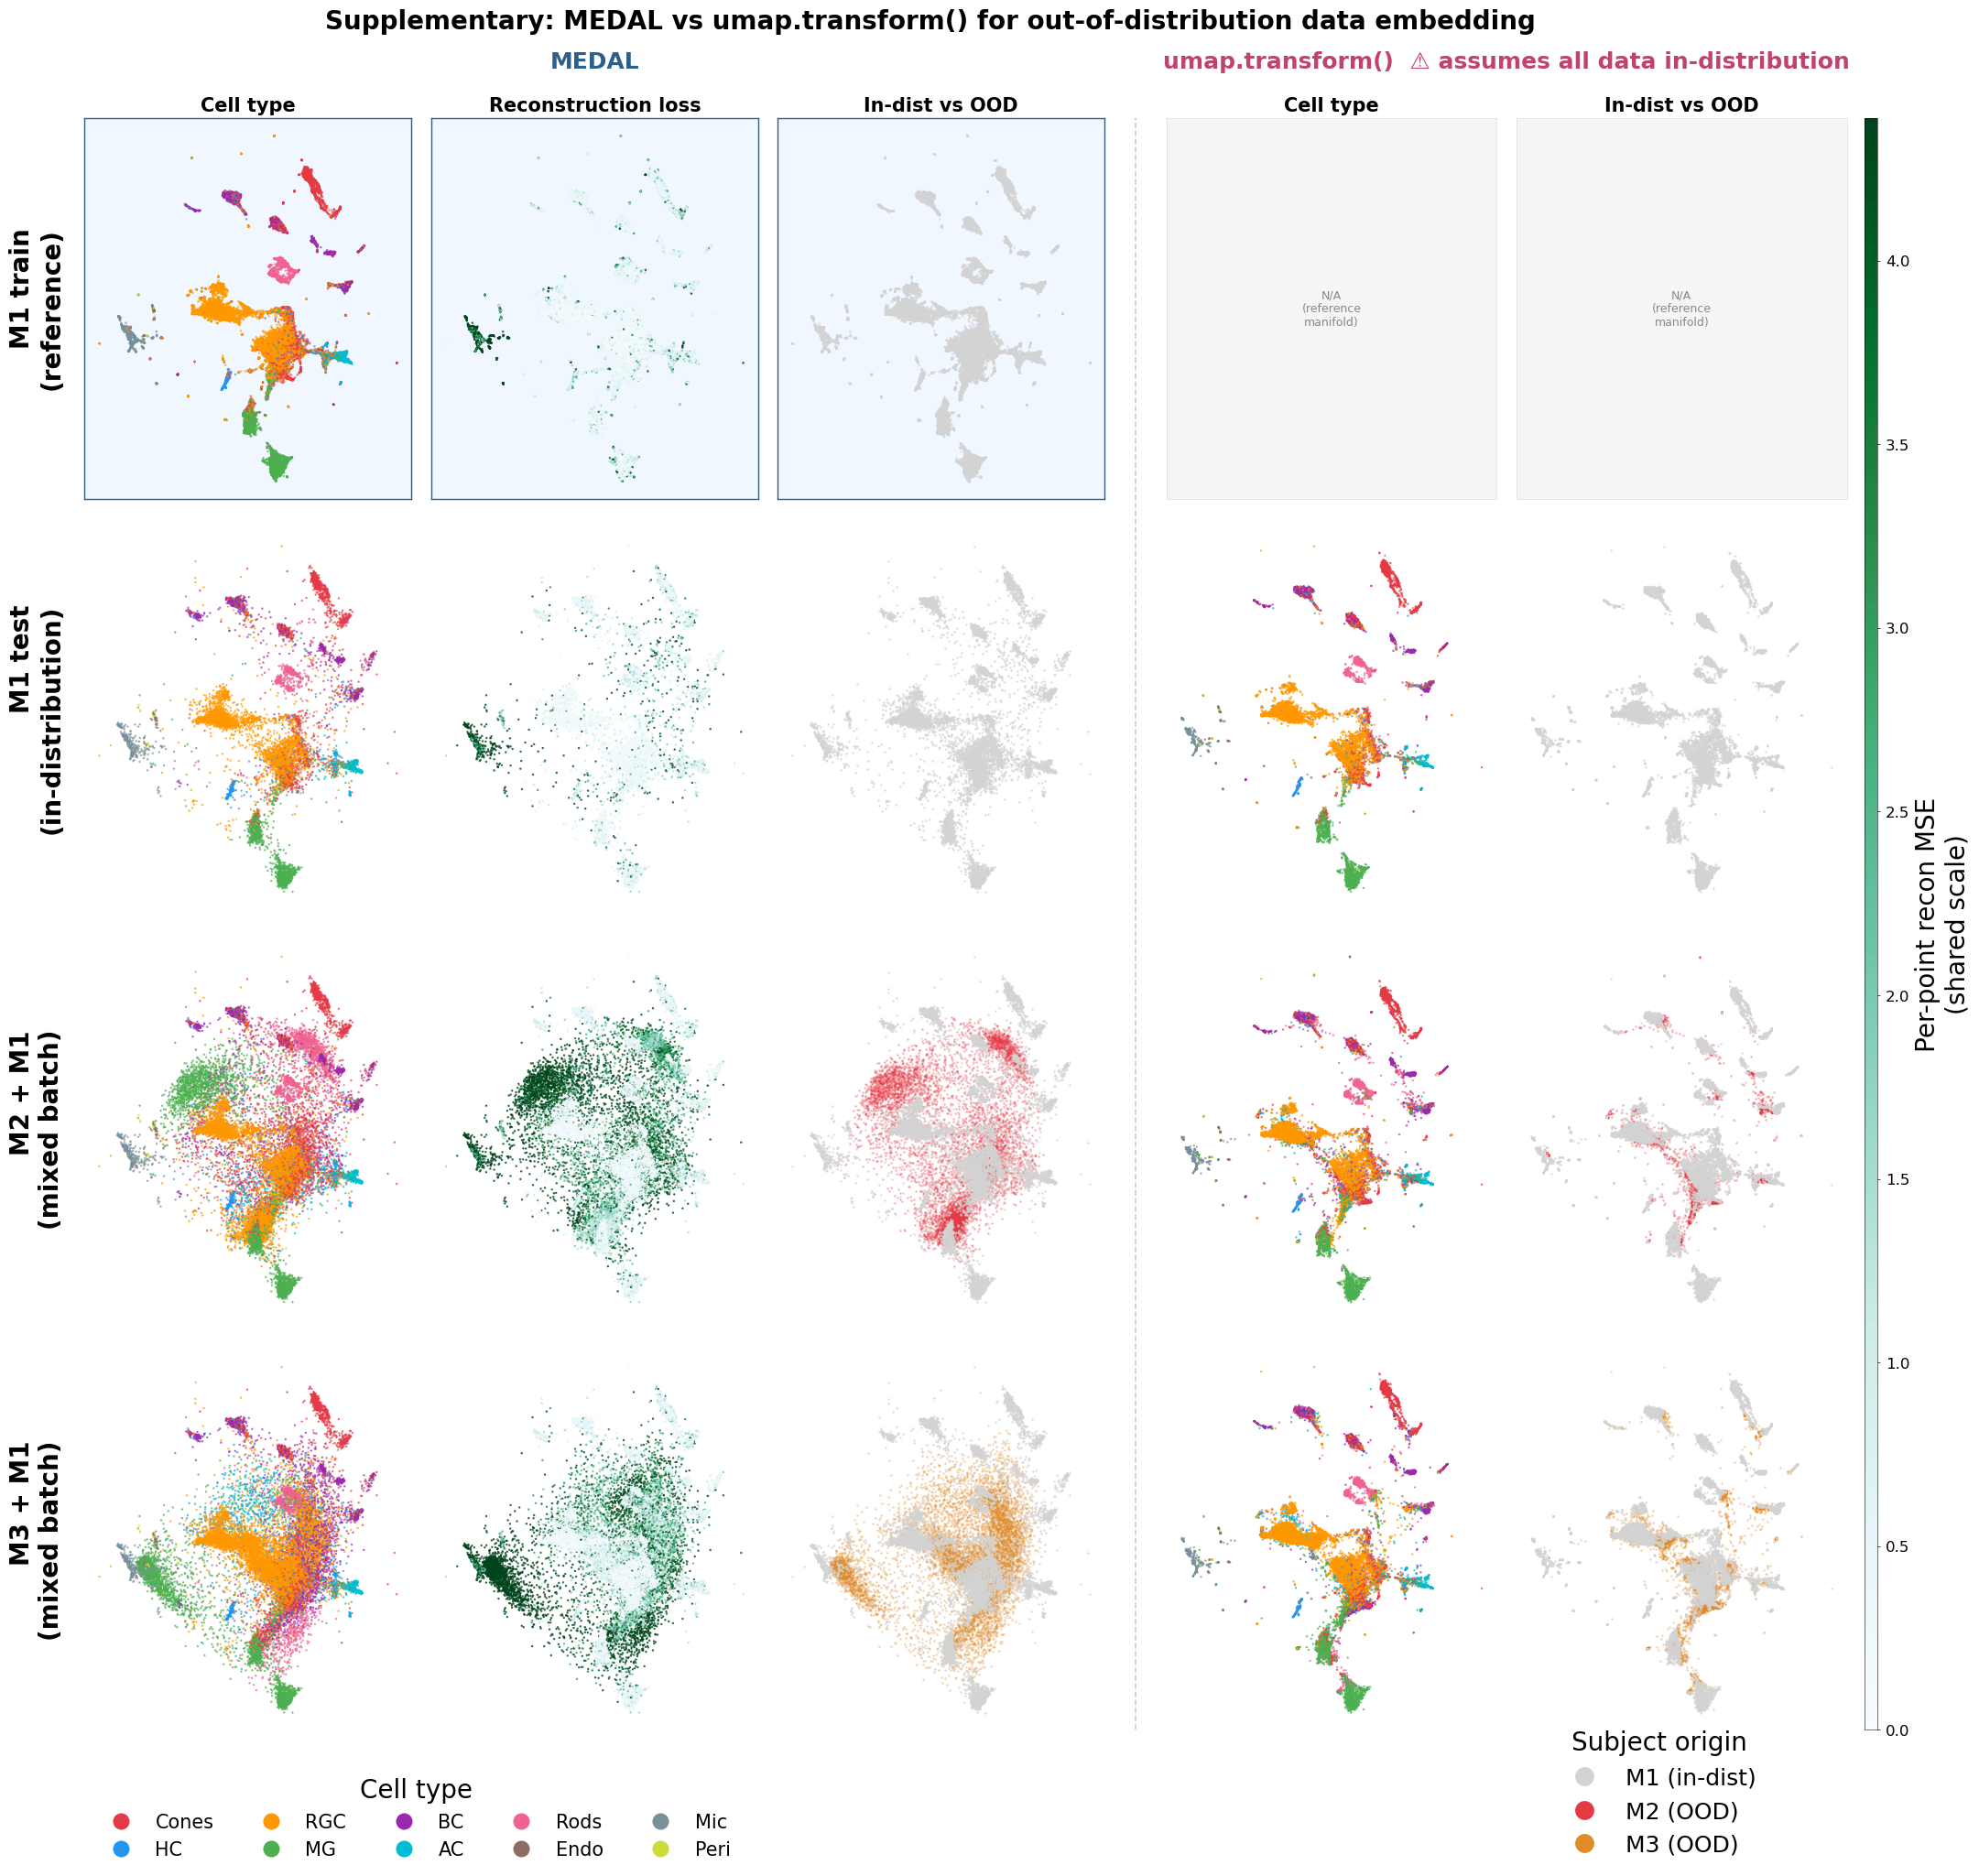

In [12]:
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':        11,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

recon_cmap   = sns.color_palette("BuGn", as_cmap=True)
indist_color = '#D3D3D3'
ood_colors   = {'M2 (OOD)': '#E63946', 'M3 (OOD)': '#E08B2A'}

all_recon   = np.concatenate([
    per_sample_recon,
    per_sample_test_recon,
    per_sample_recon_2,
    per_sample_recon_3,
])
vmax_shared = np.quantile(all_recon, 0.9)
shared_norm = plt.Normalize(vmin=0, vmax=vmax_shared)

ood_labels_train = np.array(['M1 (in-dist)'] * len(y))
ood_labels_test  = np.array(['M1 (in-dist)'] * len(y_test))
ood_labels_mix2  = m_id2
ood_labels_mix3  = m_id3

ood_palette = {
    'M1 (in-dist)': indist_color,
    'M2 (OOD)':     ood_colors['M2 (OOD)'],
    'M3 (OOD)':     ood_colors['M3 (OOD)'],
}

row_data = {
    0: (student_embed,      per_sample_recon,      y,       None,              ood_labels_train, None),
    1: (student_test_embed, per_sample_test_recon, y_test,  X_test_umap_embed, ood_labels_test,  None),
    2: (batch_embed2,       per_sample_recon_2,    y2_aug,  batch_umap_embed2, ood_labels_mix2,  'M2 (OOD)'),
    3: (batch_embed3,       per_sample_recon_3,    y3_aug,  batch_umap_embed3, ood_labels_mix3,  'M3 (OOD)'),
}

row_labels = {
    0: 'M1 train\n(reference)',
    1: 'M1 test\n(in-distribution)',
    2: 'M2 + M1\n(mixed batch)',
    3: 'M3 + M1\n(mixed batch)',
}

fig = plt.figure(figsize=(22, 20))
gs_outer = GridSpec(1, 4, figure=fig,
                    width_ratios=[3, 0.08, 2, 0.04],
                    wspace=0.04,
                    left=0.08, right=0.97,
                    top=0.94, bottom=0.06)

gs_medal = GridSpecFromSubplotSpec(4, 3, subplot_spec=gs_outer[0],
                                    hspace=0.08, wspace=0.06)

gs_umap  = GridSpecFromSubplotSpec(4, 2, subplot_spec=gs_outer[2],
                                    hspace=0.08, wspace=0.06)

cax = fig.add_subplot(gs_outer[3])
medal_axes = {}
umap_axes  = {}
for row in range(4):
    medal_axes[row] = {
        'cell':  fig.add_subplot(gs_medal[row, 0]),
        'recon': fig.add_subplot(gs_medal[row, 1]),
        'ood':   fig.add_subplot(gs_medal[row, 2]),
    }
    umap_axes[row] = {
        'cell': fig.add_subplot(gs_umap[row, 0]),
        'ood':  fig.add_subplot(gs_umap[row, 1]),
    }

# MEDAL header — centered above medal block
bbox_m0 = medal_axes[0]['cell'].get_position()
bbox_m2 = medal_axes[0]['ood'].get_position()
medal_cx = (bbox_m0.x0 + bbox_m2.x1) / 2
fig.text(medal_cx, 0.965, 'MEDAL',
         ha='center', va='bottom', fontsize=18,
         fontweight='bold', color='#2C5F8A')

# umap header — centered above umap block
bbox_u0 = umap_axes[0]['cell'].get_position()
bbox_u1 = umap_axes[0]['ood'].get_position()
umap_cx  = (bbox_u0.x0 + bbox_u1.x1) / 2
fig.text(umap_cx, 0.965, 'umap.transform()  ⚠ assumes all data in-distribution',
         ha='center', va='bottom', fontsize=18,
         fontweight='bold', color='#C0446A')

for ax, title in [(medal_axes[0]['cell'],  'Cell type'),
                  (medal_axes[0]['recon'], 'Reconstruction loss'),
                  (medal_axes[0]['ood'],   'In-dist vs OOD'),
                  (umap_axes[0]['cell'],   'Cell type'),
                  (umap_axes[0]['ood'],    'In-dist vs OOD')]:
    ax.set_title(title, fontsize=15, fontweight='bold', pad=6)

for row, label in row_labels.items():
    bbox = medal_axes[row]['cell'].get_position()
    fig.text(bbox.x0 - 0.01,
             bbox.y0 + bbox.height / 2,
             label, ha='right', va='center',
             fontsize=20, fontweight='bold', rotation=90)

def clean_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

def plot_ood(ax, Z, ood_labels, ood_key):
    if ood_key is None:
        ax.scatter(Z[:, 0], Z[:, 1],
                   c=indist_color, s=3, linewidths=0,
                   alpha=0.8, rasterized=True)
    else:
        ood_mask = ood_labels == ood_key
        m1_mask  = ood_labels == 'M1 (in-dist)'
        ax.scatter(Z[ood_mask, 0], Z[ood_mask, 1],
                   c=ood_palette[ood_key], s=3, linewidths=0,
                   alpha=0.4, rasterized=True, zorder=1)
        ax.scatter(Z[m1_mask, 0], Z[m1_mask, 1],
                   c=indist_color, s=3, linewidths=0,
                   alpha=0.8, rasterized=True, zorder=2)
    clean_ax(ax)

for row, (embed, recon, labels, umap_embed, ood_labels, ood_key) in row_data.items():
    Z = embed.detach().numpy() if hasattr(embed, 'detach') else np.array(embed)

    # ── MEDAL block ────────────────────────────────────────────────────────────
    medal_axes[row]['cell'].scatter(
        Z[:, 0], Z[:, 1],
        c=[c_dict.get(ct, '#aaaaaa') for ct in labels],
        s=3, linewidths=0, alpha=0.7, rasterized=True
    )
    clean_ax(medal_axes[row]['cell'])
    medal_axes[row]['recon'].scatter(
        Z[:, 0], Z[:, 1],
        c=recon, cmap=recon_cmap, norm=shared_norm,
        s=3, linewidths=0, alpha=0.8, rasterized=True
    )
    clean_ax(medal_axes[row]['recon'])
    plot_ood(medal_axes[row]['ood'], Z, ood_labels, ood_key)
    if row == 0:
        for ax in [medal_axes[row]['cell'], medal_axes[row]['recon'],
                   medal_axes[row]['ood']]:
            ax.set_facecolor('#f0f7ff')
            ax.set_axis_on()
            for spine in ax.spines.values():
                spine.set_edgecolor('#2C5F8A')
                spine.set_linewidth(1.0)
            ax.set_xticks([])
            ax.set_yticks([])

    if umap_embed is None:
        for ax in umap_axes[row].values():
            clean_ax(ax)
            ax.set_facecolor('#f5f5f5')
            ax.text(0.5, 0.5, 'N/A\n(reference\nmanifold)',
                    ha='center', va='center', fontsize=9,
                    color='#888888', transform=ax.transAxes)
            ax.set_axis_on()
            for spine in ax.spines.values():
                spine.set_edgecolor('#dddddd')
                spine.set_linewidth(0.5)
            ax.set_xticks([])
            ax.set_yticks([])
    else:
        Z_umap = umap_embed if isinstance(umap_embed, np.ndarray) else np.array(umap_embed)
        umap_axes[row]['cell'].scatter(
            Z_umap[:, 0], Z_umap[:, 1],
            c=[c_dict.get(ct, '#aaaaaa') for ct in labels],
            s=3, linewidths=0, alpha=0.7, rasterized=True
        )
        clean_ax(umap_axes[row]['cell'])
        plot_ood(umap_axes[row]['ood'], Z_umap, ood_labels, ood_key)

bbox_gap = gs_outer[1].get_position(fig)
fig.add_artist(plt.Line2D(
    [bbox_gap.x0 + bbox_gap.width / 2, bbox_gap.x0 + bbox_gap.width / 2],
    [0.06, 0.94],
    transform=fig.transFigure,
    color='#cccccc', linewidth=1.2, linestyle='--'
))


sm = plt.cm.ScalarMappable(cmap=recon_cmap, norm=shared_norm)
cb = fig.colorbar(sm, cax=cax, orientation='vertical')
cb.set_label('Per-point recon MSE\n(shared scale)', fontsize=20, labelpad=4)
cb.ax.tick_params(labelsize=12, width=0.5, length=2.5)
cb.outline.set_linewidth(0.4)
ct_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markersize=7, label=ct)
    for ct, color in c_dict.items()
]
fig.legend(
    handles=ct_handles,
    loc='lower left', bbox_to_anchor=(0.08, -0.02),
    frameon=False, fontsize=15, ncol=5,
    title='Cell type', title_fontsize=20, markerscale=2,
)

ood_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markersize=8, label=label)
    for label, color in ood_palette.items()
]
fig.legend(
    handles=ood_handles,
    loc='lower right', bbox_to_anchor=(0.92, -0.02),
    frameon=False, fontsize=18,
    title='Subject origin', title_fontsize=20,markerscale=2
)

fig.suptitle(
    'Supplementary: MEDAL vs umap.transform() for out-of-distribution data embedding',
    fontsize=20, fontweight='bold', y=1
)

plt.show()

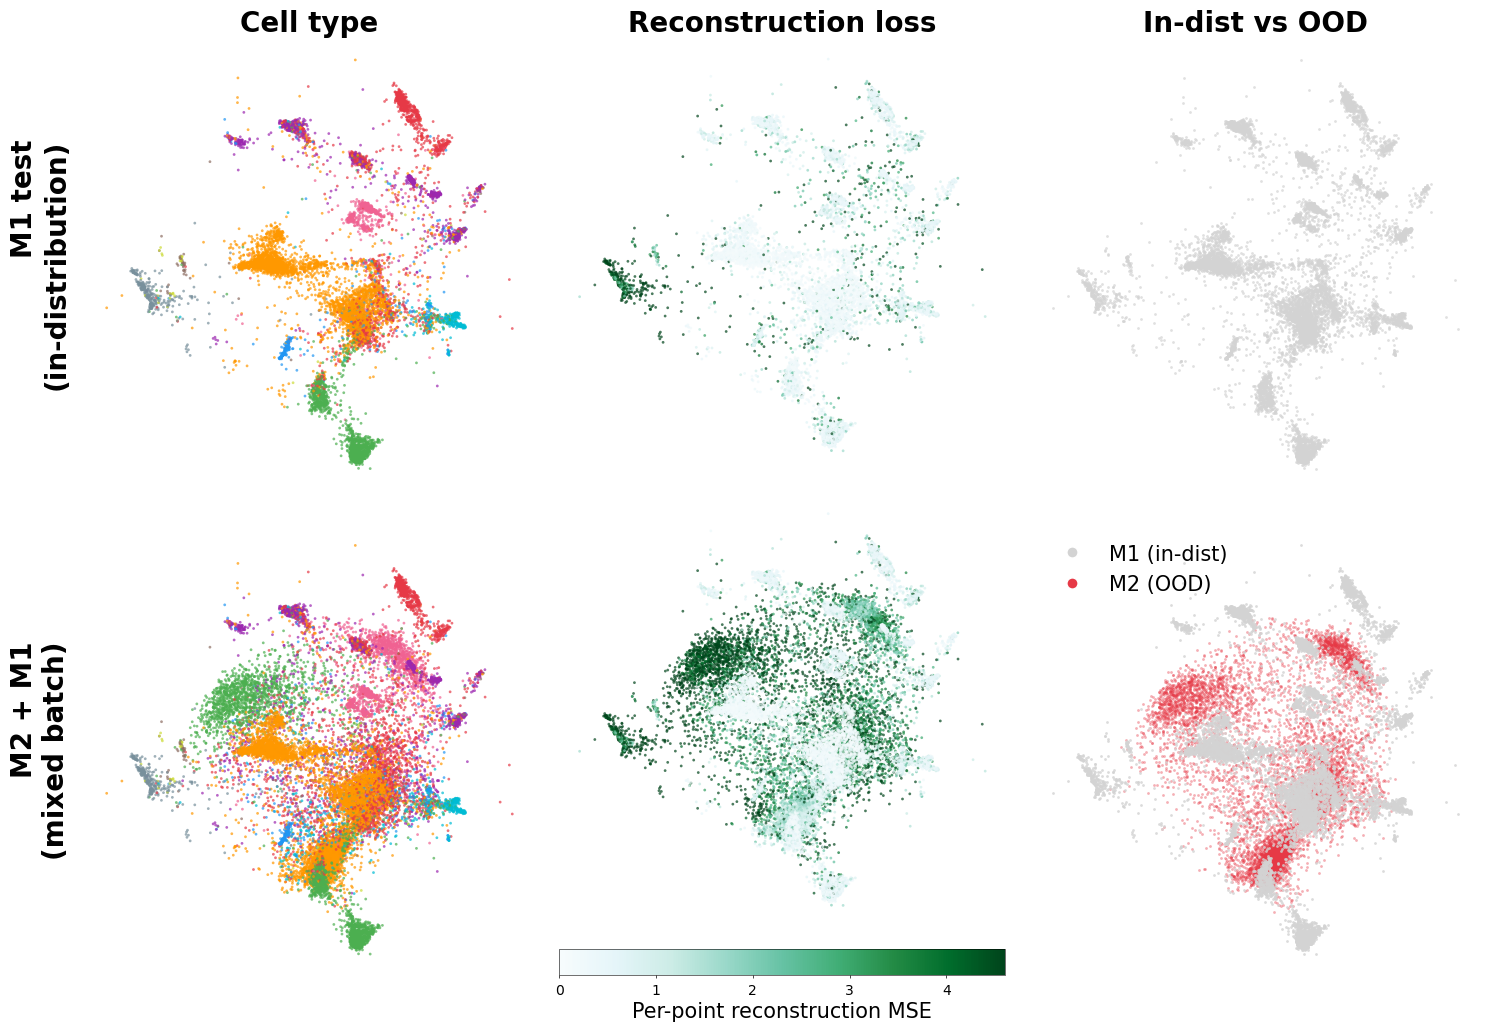

In [13]:
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':        11,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

recon_cmap = sns.color_palette("BuGn", as_cmap=True)

# shared recon colorscale across both rows
all_recon   = np.concatenate([per_sample_test_recon, per_sample_recon_2])
vmax_shared = np.quantile(all_recon, 0.9)
shared_norm = plt.Normalize(vmin=0, vmax=vmax_shared)

indist_color = '#D3D3D3'   # grey = M1 (in-distribution)
ood_color    = '#E63946'   # red  = M2 (out-of-distribution)

ood_labels_test = np.array(['M1 (in-dist)'] * len(y_test))
ood_labels_mix  = np.array(['M2 (OOD)'] * len(y2)+['M1 (in-dist)'] * len(y_test))

ood_palette = {
    'M1 (in-dist)': indist_color,
    'M2 (OOD)':     ood_color,
}

fig = plt.figure(figsize=(16, 11))
gs_outer = GridSpec(1, 3, figure=fig, wspace=0.06,
                    left=0.1, right=0.97, top=0.93, bottom=0.08)

gs_col0 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[0], hspace=0.08)
gs_col2 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[2], hspace=0.08)
gs_col1 = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs_outer[1],
                                   height_ratios=[1, 1, 0.06], hspace=0.08)

ax_test_cell  = fig.add_subplot(gs_col0[0])
ax_mix_cell   = fig.add_subplot(gs_col0[1])

ax_test_recon = fig.add_subplot(gs_col1[0])
ax_mix_recon  = fig.add_subplot(gs_col1[1])
cax           = fig.add_subplot(gs_col1[2])  

ax_test_ood   = fig.add_subplot(gs_col2[0])
ax_mix_ood    = fig.add_subplot(gs_col2[1])

col_titles = ['Cell type', 'Reconstruction loss', 'In-dist vs OOD']
for ax, title in zip([ax_test_cell, ax_test_recon, ax_test_ood], col_titles):
    ax.set_title(title, fontsize=20, fontweight='bold', pad=6)

for ax, label in [(ax_test_cell, 'M1 test\n(in-distribution)'),
                  (ax_mix_cell,  'M2 + M1\n(mixed batch)')]:
    bbox = ax.get_position()
    fig.text(bbox.x0 - 0.01,
             bbox.y0 + bbox.height / 2,
             label, ha='right', va='center',
             fontsize=20, fontweight='bold', rotation=90)

Z_test = student_test_embed.detach().numpy() if hasattr(student_test_embed, 'detach') \
         else np.array(student_test_embed)
ax_test_cell.scatter(Z_test[:, 0], Z_test[:, 1],
                     c=[c_dict[ct] for ct in y_test],
                     s=4, linewidths=0, alpha=0.7, rasterized=True)
clean_ax(ax_test_cell)
ax_test_recon.scatter(Z_test[:, 0], Z_test[:, 1],
                      c=per_sample_test_recon, cmap=recon_cmap,
                      norm=shared_norm, s=4, linewidths=0,
                      alpha=0.7, rasterized=True)
clean_ax(ax_test_recon)

ax_test_ood.scatter(Z_test[:, 0], Z_test[:, 1],
                    c=indist_color, s=4, linewidths=0,
                    alpha=0.7, rasterized=True)
clean_ax(ax_test_ood)
Z_mix = batch_embed2.detach().numpy() if hasattr(batch_embed2, 'detach') \
        else np.array(batch_embed2)
ax_mix_cell.scatter(Z_mix[:, 0], Z_mix[:, 1],
                    c=[c_dict.get(ct, '#aaaaaa') for ct in y2_aug],
                    s=4, linewidths=0, alpha=0.7, rasterized=True)
clean_ax(ax_mix_cell)
ax_mix_recon.scatter(Z_mix[:, 0], Z_mix[:, 1],
                     c=per_sample_recon_2, cmap=recon_cmap,
                     norm=shared_norm, s=4, linewidths=0,
                     alpha=0.7, rasterized=True)
clean_ax(ax_mix_recon)
m2_mask = ood_labels_mix == 'M2 (OOD)'
m1_mask = ood_labels_mix == 'M1 (in-dist)'

ax_mix_ood.scatter(Z_mix[m2_mask, 0], Z_mix[m2_mask, 1],
                   c=ood_color, s=4, linewidths=0,
                   alpha=0.4, rasterized=True, zorder=1)   
ax_mix_ood.scatter(Z_mix[m1_mask, 0], Z_mix[m1_mask, 1],
                   c=indist_color, s=4, linewidths=0,
                   alpha=0.8, rasterized=True, zorder=2)   
clean_ax(ax_mix_ood)

sm = plt.cm.ScalarMappable(cmap=recon_cmap, norm=shared_norm)
cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label('Per-point reconstruction MSE', fontsize=15, labelpad=3)
cb.ax.tick_params(labelsize=10, width=0.5, length=2.5)
cb.outline.set_linewidth(0.4)
ood_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markersize=8, label=label)
    for label, color in ood_palette.items()
]
ax_mix_ood.legend(
    handles=ood_handles,
    loc='upper left', frameon=False,
    facecolor='white', edgecolor='#cccccc',
    framealpha=0.9, fontsize=15,
)

fig.subplots_adjust(left=0.1)

plt.show()

In [3]:
import scanpy as sc
adata = sc.read_h5ad(Path(PATH_PREFIX)/ "GSE118546_fovea.h5ad")
markers = {
    "Rods": ["RHO", "PDC", "NRL", "SAG", "GNAT1", "GNGT1", "NR2E3", "GNB1"],
    "Cones": ["ARR3", "RCVRN", "GNAT2", "GNGT2", "OPN1LW", "OPN1SW", "OPN1MW", "PDE6H", "GUCA1A"],
    "HC": ["LHX1", "ONECUT1", "ONECUT2", "CALB1"],
    "BC": ["VSX2", "OTX2", "GRM6", "PRKCA", "TRPM1", "GRIK1", "VSX1", "CABP5"],
    "AC": ["TFAP2A", "TFAP2B", "TFAP2C", "GAD1", "GAD2", "SLC6A9", "C1QL1", "C1QL2"],
    "RGC": ["RBPMS", "POU4F1", "POU4F2", "POU4F3", "THY1", "SLC17A6", "NEFL", "NEFM", "SNCG"],
    "MG": ["RLBP1", "GLUL", "APOE", "CRABP1", "CLU", "SLC1A3", "DKK3", "CRYM"],
    "Peri": ["RGC5", "MGP", "KCNJ8", "MYL9", "COL4A1"], 
    "Mic": ["C1QA", "C1QB", "C1QC", "HEXB", "CTSS", "P2RY12", "TMEM119", "B2M"],
    "Endo":	["CLDN5", "IGFBP7", "COL4A1"]
}

# Score each program
for k, genes in markers.items():
    present = [g for g in genes if g in adata.var_names]
    if present:
        sc.tl.score_genes(adata, gene_list=present, score_name=f"score_{k}", use_raw=False)

# Simple rule-based assignment from scores (you can refine later)
order = list(markers.keys())  # priority order
scores = [f"score_{k}" for k in order if f"score_{k}" in adata.obs]
adata.obs["celltype_guess"] = pd.Series(index=adata.obs_names, dtype="object")

if scores:
    score_mat = adata.obs[scores].to_numpy()
    best = score_mat.argmax(1)
    adata.obs["celltype_guess"] = np.array([order[i] for i in best])

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var["highly_variable"]].copy()


In [4]:
data_to_save = pd.DataFrame(adata.X.toarray(), index = adata.obs.index, columns= adata.var_names)
df = (
    data_to_save.assign(_strat=adata.obs['macaque_id'])
    .groupby('_strat', group_keys=False)
    .apply(lambda x: x.sample(frac=0.2, random_state=0))
    .drop(columns='_strat')
)

# Align the label series to the sampled index
allM_y = adata.obs['macaque_id'].loc[df.index]

/tmp/ipykernel_46678/705878984.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_to_save.assign(_strat=adata.obs['macaque_id'])
/tmp/ipykernel_46678/705878984.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.2, random_state=0))


In [5]:
alltypes_y = adata.obs['celltype_guess'].loc[allM_y.index]

In [6]:
from openTSNE import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
df = StandardScaler().fit_transform(df)
df = PCA(n_components=100, random_state=0).fit_transform(df)
df = pd.DataFrame(df)

In [9]:
from medal.teacher import get_teacher_embeddings

In [10]:
Z_tsne15 =  get_teacher_embeddings("tsne", df.to_numpy(), perplexity=15, random_state=0)

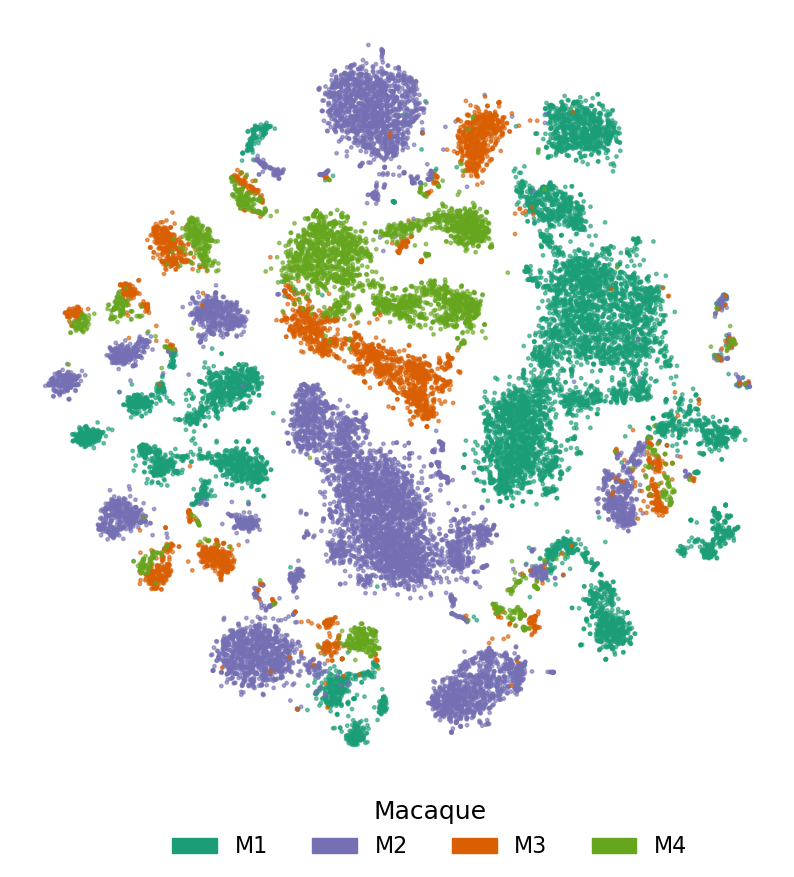

In [24]:
palette = {
    'M1': '#1B9E77',
    'M2': '#7570B3',
    'M3': '#D95F02',
    'M4': '#66A61E',
}

labels = allM_y.values
colors = [palette[l] for l in labels]

plt.figure(figsize=(10, 10))

plt.scatter(Z_tsne15[:, 0], Z_tsne15[:, 1], c=colors, s=6, alpha=0.6, rasterized=True)
plt.xticks([])
plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)

legend_handles = [
    mpatches.Patch(color=col, label=mac)
    for mac, col in palette.items()
]
plt.legend(
    handles=legend_handles,
    title='Macaque',
    title_fontsize=18,
    fontsize=16,
    loc='best',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.9, 0),
)

plt.show()

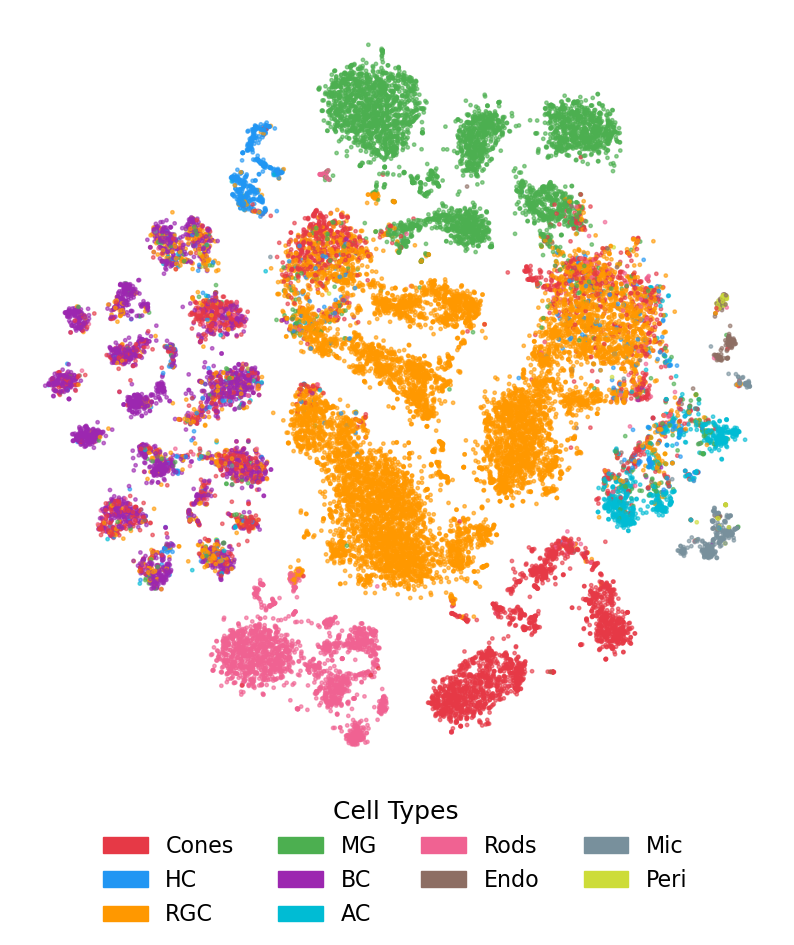

In [27]:
palette = {
    'Cones': '#E63946',  # red
    'HC':    '#2196F3',  # blue
    'RGC':   '#FF9800',  # orange
    'MG':    '#4CAF50',  # green
    'BC':    '#9C27B0',  # purple
    'AC':    '#00BCD4',  # cyan
    'Rods':  '#F06292',  # pink
    'Endo':  '#8D6E63',  # brown
    'Mic':   '#78909C',  # slate
    'Peri':  '#CDDC39',  # yellow-green
}

labels = alltypes_y.values
colors = [palette[l] for l in labels]

plt.subplots(figsize=(10, 10))

plt.scatter(Z_tsne15[:, 0], Z_tsne15[:, 1], c=colors, s=6, alpha=0.6, rasterized=True)
plt.xticks([])
plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
legend_handles = [
    mpatches.Patch(color=col, label=mac)
    for mac, col in palette.items()
]
plt.legend(
    handles=legend_handles,
    title='Cell Types',
    title_fontsize=18,
    fontsize=16,
    loc='best',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.9, 0),
)

plt.show()

In [36]:
data_to_save['labels'] = adata.obs['celltype_guess'].values
data_to_save['macaque_id'] = adata.obs['macaque_id'].values
data_to_save

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,labels,macaque_id
0,-2.954079,-4.345200,-1.378243,6.311030,6.057581,-1.113562,-1.378721,-0.578843,3.872104,1.445541,...,-0.307703,-0.053048,0.283342,0.257846,-0.060792,0.469997,0.019518,0.396803,Cones,M1
1,-0.748709,-0.910819,-2.505191,0.049146,-0.133986,-0.297894,-0.249767,-2.112056,1.378044,2.826946,...,-1.110531,-0.236533,1.131640,-0.363041,0.068316,0.076998,0.038659,-0.425274,HC,M1
2,5.387257,18.183874,9.235629,0.314976,0.749108,-1.093879,-1.147228,-2.190934,4.936161,1.290498,...,0.424632,-1.461540,-1.065258,-0.447340,1.581669,-0.028073,-0.965883,-1.393167,MG,M1
3,3.214907,18.306976,9.395370,0.884092,0.480569,-0.492026,0.234518,-0.418870,2.569574,-1.341781,...,-0.126661,1.020804,0.819205,-0.285417,0.283425,-1.125957,-0.670596,-0.240535,MG,M1
4,-2.638522,-3.914229,-2.536319,9.365832,9.040171,-2.092767,0.569923,-2.504452,6.203900,1.258671,...,-0.799825,-0.260420,-0.005216,0.115004,-0.409910,0.456418,-0.263309,-0.573274,Cones,M1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131995,-2.359880,-1.812841,-3.150257,5.969696,5.059112,-0.574527,0.905811,-0.159201,-3.874022,-1.607628,...,-0.030396,0.213226,0.820411,-0.165053,-0.277870,0.106320,-0.629057,0.158088,RGC,M4
131996,-0.812330,0.284670,-4.603324,-1.792543,-2.836862,0.293485,0.324496,0.430741,-3.573377,-1.326716,...,0.023158,-0.375778,-0.210033,0.222905,0.461109,0.418816,0.229618,0.097845,RGC,M4
131997,-0.219753,-0.518592,-5.813065,-4.204962,-3.344605,-0.650470,-1.024325,-3.435745,-2.681987,-1.554515,...,-0.116582,-0.041569,0.225468,-0.427800,0.223795,-0.180377,0.171051,0.010508,RGC,M4
131998,-5.383344,-11.959335,12.954655,-0.600410,-0.384019,2.122341,-12.460854,2.609831,-5.019061,-1.440738,...,1.067104,2.145916,-1.400273,0.352513,0.674120,-1.319836,0.551910,0.832862,Cones,M4


In [37]:
data_to_save.to_csv('preprocessed_all_macaques.csv', index=False)